# Evaluation of Vision Models

## 1 Overview

This notebook uses the RAF-DB dataset to compare seven pretrained models for facial expression recognition [1]. The models are evaluated on the seven RAF-DB emotion classes anger, disgust, fear, happiness, neutral, sadness and surprise. The provided RAF-DB train and test splits are reused as the validation and testing sets so that no image appears in both model selection and final testing.

The models are compared using macro-F1 as the main measure, and the top candidate is chosen on the validation split. Accuracy, macro-precision, macro-recall, loading time, and inference time are also noted. On the reserved testing split, just the chosen model is assessed. There is no fine-tuning or training done. Every result shows true cross-dataset transfer because six of the candidates were trained on FER2013 (or related mixtures) and the DDAMFN candidate on AffectNet-7 none were trained on RAF-DB.

## 2 Importing Libraries

The facial expression evaluation toolchain, which combines three distinct model execution methods with standard image handling, is imported in this section. Torchvision transforms, resizes, and normalises images for the models that require manual preprocessing, while Pillow reads each RAF-DB image and converts it to RGB. Because the seven candidates are not consistent, three model interfaces are imported timm provides the Swin-Tiny backbone loaded from a custom checkpoint, a downloaded DDAMFN network module is imported for the specialised facial-expression model, and the Hugging Face pipeline runs the off-the-shelf classifiers. While NumPy and pandas manage arrays and tables and matplotlib creates the comparison chart and confusion matrix, Scikit-learn once more offers the multiclass metrics, ROC, and precision-recall utilities, maintaining the vision methodology in line with the other modalities. GPU execution, the runtime download of the DDAMFN code and checkpoint, and the importability of the downloaded code are all supported by torch, urllib, and sys.

In [1]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# import required libraries
from pathlib import Path
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import pipeline
import timm
from huggingface_hub import hf_hub_download
from timm.data import resolve_model_data_config, create_transform
import sys
from torchvision import transforms
import urllib.request
from sklearn.metrics import roc_curve, auc, precision_recall_curve

The notebook can load RAF-DB, run seven architecturally distinct models through the interface each requires, and score them all under a single operation when these imports are available. Because the DDAMFN model is fetched at runtime rather being bundled, the import list itself shows how its license is honored. This deliberate design choice can be looked at by importing urllib and sys here. The tqdm widget warning is cosmetic, as in the other notebooks. The seven candidates are registered and the shared settings are fixed in the next step.

## 3 Evaluation Settings and Candidate Models

This section fixes the experimental conditions and enumerates the candidates. The RAF-DB image folders, label files, and a specific output folder are defined once, the GPU is chosen when available, and a random seed is provided for reproducibility. The seven candidate models are registered in one dictionary, each entry recording the architecture, the dataset it was trained on, a batch size and, where the model needs special handling, a loader key. The candidates were selected to cover a variety of training data and contemporary image architectures, including Vision Transformer, ResNet-50, ConvNeXt-Tiny, Swin Transformer, and the attention-based DDAMFN. This ensures that the comparison represents true architectural diversity rather than slight variations [2].

In [3]:
# set seed to 42
SEED = 42

In [4]:
# seed NumPy for reproducibility
np.random.seed(SEED)
# seed PyTorch for reproducibility
torch.manual_seed(SEED)

In [5]:
# set devide to 0 if cuda is available
device = 0 if torch.cuda.is_available() else -1

In [6]:
# rafdb folder
rafdb_folder = Path("../../data/raw/raf_db")
# dataset folder
dataset_folder = (rafdb_folder / "DATASET")
# validaiton folder
validation_folder = (dataset_folder / "train")
# testing folder
testing_folder = (dataset_folder / "test")
# validaiton labels file
validation_labels_file = (rafdb_folder / "train_labels.csv")
# testing labels file
testing_labels_file = (rafdb_folder / "test_labels.csv")

In [7]:
# output folder
output_folder = Path("outputs/vision")
# create the folder
output_folder.mkdir(parents=True, exist_ok=True)

In [8]:
# vision emotions list
vision_emotions = ["anger", "disgust", "fear", "happiness", "neutral", "sadness", "surprise"]

In [9]:
# define models
models = {
    # ViT model
    "ViT": {
        "model_id": "trpakov/vit-face-expression",
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    },

    # ResNet-50 model
    "ResNet-50": {
        "model_id": "Celal11/resnet-50-finetuned-FER2013-0.003",
        "architecture": "ResNet-50",
        "training_data": "FER2013",
        "batch_size": 16
    },

    # ViT-Mixed-Datasets model
    "ViT-Mixed-Datasets": {
        "model_id": "mo-thecreator/vit-Facial-Expression-Recognition",
        "architecture": "Vision Transformer",
        "training_data": "FER2013, MMI and AffectNet",
        "batch_size": 16
    },

    # ViT-FER2013 model
    "ViT-FER2013": {
        "model_id": "abhilash88/face-emotion-detection",
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    },

    # ConvNeXt-Tiny model
    "ConvNeXt-Tiny": {
        "model_id": "Aaryan333/convnext-tiny-finetuned-fer2013",
        "architecture": "ConvNeXt-Tiny",
        "training_data": "FER2013",
        "batch_size": 16
    },

    # Swin-Tiny model
    "Swin-Tiny": {
        "model_id": "Ram9999Pabb/emotion-swin-model",
        "architecture": "Swin Transformer",
        "training_data": "FER2013",
        "batch_size": 16,
        "loader": "swin_custom"
    },
    # DDAMFN-AffectNet7 model
    "DDAMFN-AffectNet7": {
        "architecture": "DDAMFN (MixedFeatureNet)",
        "training_data": "AffectNet-7",
        "batch_size": 1,
        "loader": "ddamfn"
    }
}

In [10]:
# model information list
model_information = []

In [11]:
for model_name, details in models.items():
    # model information append to list
    model_information.append({
        "Model": model_name,
        "Architecture": details["architecture"],
        "Training Data": details["training_data"],
        "RAF-DB Training": "No",
        "Batch Size": details["batch_size"]
    })

In [12]:
# model information dataframe
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Architecture,Training Data,RAF-DB Training,Batch Size
0,ViT,Vision Transformer,FER2013,No,16
1,ResNet-50,ResNet-50,FER2013,No,16
2,ViT-Mixed-Datasets,Vision Transformer,"FER2013, MMI and AffectNet",No,16
3,ViT-FER2013,Vision Transformer,FER2013,No,16
4,ConvNeXt-Tiny,ConvNeXt-Tiny,FER2013,No,16
5,Swin-Tiny,Swin Transformer,FER2013,No,16
6,DDAMFN-AffectNet7,DDAMFN (MixedFeatureNet),AffectNet-7,No,1


In [13]:
# print statements
print("Number of models:", len(models))
print("Emotions:", vision_emotions)

Number of models: 7
Emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


**Analysis:** 

Seven candidate models are compared, covering five architecture families. Six were trained using DDAMFN-AffectNet7 on AffectNet-7 and FER2013 or similar combinations. Since none of the seven models were trained on RAF-DB, the RAF-DB evaluation that follows assesses cross-dataset generalization to a dataset that none of the models have seen the unbiased and fair environment necessary for model selection.

The evaluation loop just iterates over this dictionary and assigns each contender to the appropriate loader, keeping the remainder of the notebook model-agnostic and the comparison fair. This dictionary serves as the only place where model selections are made. An essential property is made clear by the training-data field none of the seven contenders were trained on RAF-DB, while six of them were trained on FER2013 or similar mixtures and DDAMFN on AffectNet-7. Therefore, evaluating on RAF-DB evaluates true cross-dataset transfer to a dataset that no model has seen. This is particularly important for the application because no training set will ever match the faces of its users. The notebook loads RAF-DB when the candidates have been defined.

## 4 Load RAF-DB Dataset

To make the comparison fair and the rest of the notebook model-agnostic, the evaluation loop simply iterates over this dictionary, assigning each competitor to the proper loader. Model choices are decided exclusively in this dictionary. An essential property is made clear by the training-data field none of the seven contenders were trained on RAF-DB, while six of them were trained on FER2013 or similar mixtures and DDAMFN on AffectNet-7. As a result, actual cross-dataset transfer to a dataset that no model has seen is evaluated on RAF-DB. This is particularly important for the application because no training set will ever match the faces of its users. After the candidates are defined, the notebook loads RAF-DB.

In [14]:
# label mapping
label_mapping = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happiness",
    5: "sadness",
    6: "anger",
    7: "neutral"
}

In [15]:
# load raf db split
def load_rafdb_split(labels_file, image_folder):
    # data read
    data = pd.read_csv(labels_file)
    data = data[["image", "label"]].copy()
    data["emotion"] = data["label"].map(label_mapping)
    data["image_path"] = data.apply(
        lambda row: (image_folder / str(row["label"]) / str(row["image"])),axis=1)
    # compute missing files
    missing_files = (~data["image_path"].apply(lambda path: path.is_file()))
    # if missing files
    if missing_files.any():
        # raise FileNotFoundError
        raise FileNotFoundError(f"{missing_files.sum()} images could not be located")
    return data.reset_index(drop=True)

In [16]:
# validation and testing data
validation_data = load_rafdb_split(validation_labels_file, validation_folder)
testing_data = load_rafdb_split(testing_labels_file, testing_folder)

In [17]:
# print statements
print("Validation images:", len(validation_data))
print("Testing images:", len(testing_data))

Validation images: 12271
Testing images: 3068


In [18]:
# concatenate class distribution
class_distribution = pd.concat([
    validation_data["emotion"].value_counts().reindex(vision_emotions).rename("Validation"),
    testing_data["emotion"].value_counts().reindex(vision_emotions).rename("Testing")
], axis=1).fillna(0).astype(int)

**Analysis:** 

RAF-DB provides 12,271 validation images and 3,068 testing images. There is a significant imbalance in the dataset fear is uncommon (281/74), whereas happiness dominates (4,772 validation/1,185 testing). Because of this imbalance, macro-averaged metrics are employed throughout. This prevents a model from scoring well by favoring the majority happiness class, and also predicts the weaker per-class outcomes for the rare emotions that will be observed later.

In [19]:
# class distribution
class_distribution

,Validation,Testing
emotion,,
anger,705,162
disgust,717,160
fear,281,74
happiness,4772,1185
neutral,2524,680
sadness,1982,478
surprise,1290,329


Displaying the class counts up front makes RAF-DB's pronounced imbalance explicit: happiness dominates with thousands of images while fear has only a few hundred, and this is exactly why every metric in the notebook is macro-averaged and why the final section reports per-class results rather than a single accuracy. Verifying file existence at load time is a small but important robustness measure that prevents silent failures deep inside the inference loop. RAF-DB provides 12,271 validation and 3,068 testing images, a substantial evaluation set for a facial task. The label vocabularies are aligned and the photos are prepared in the next part.

## 5 Align Emotion Labels and Prepare Images

This section defines an alias table that standardises each model's output onto the seven shared RAF-DB emotion names, along with a helper that loads each image as RGB, because the candidate models label expressions differently. Some use words like happy or happiness, while others use numeric strings like label_0 through label_6. Here, standardising both the image format and the label space allows the downstream inference processes to assume a single, consistent representation.

In [20]:
# define label aliases
label_aliases = {
    "angry": "anger",
    "anger": "anger",

    "disgusted": "disgust",
    "disgust": "disgust",

    "fearful": "fear",
    "fear": "fear",

    "happy": "happiness",
    "happiness": "happiness",
    "joy": "happiness",

    "neutral": "neutral",

    "sad": "sadness",
    "sadness": "sadness",
    "surprised": "surprise",
    "surprise": "surprise",

    "label_0": "anger",
    "label_1": "disgust",
    "label_2": "fear",
    "label_3": "happiness",
    "label_4": "sadness",
    "label_5": "surprise",
    "label_6": "neutral"
}

In [21]:
# normalise vision labels
def normalise_vision_label(label):
    # labels
    label = str(label).strip().lower()
    return label_aliases.get(label, label)

In [22]:
# load the image
def load_image(image_path):
    return Image.open(image_path).convert("RGB")

In [23]:
# sample image
sample_image = load_image(validation_data.loc[0, "image_path"])

In [24]:
# print statements
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Dataset emotions:",sorted(validation_data["emotion"].unique()))

Image size: (100, 100)
Image mode: RGB
Dataset emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


**Analysis:** 

RAF-DB images are small aligned 100x100 RGB face crops, and all seven expected emotions are present in the validation split. Instead of expecting a single fixed transform, the per-model procedures below resize and normalise the photos to whatever each architecture wants because each candidate model expects its own input size and normalisation.

A prediction from any of the seven models can be scored against RAF-DB on exactly equal terms when labels are aligned and a common image loader is in place. Additionally, the problematic but frequent situation of numerically labelled models is addressed directly rather than being left to chance. This prevents a model's score from being lowered for reasons unrelated to its actual ability due to the quiet label mismatch problem. Each candidate is subjected to the same alignment. The per-architecture inference methods can now be defined in the notebook.

## 6 Define Model Prediction Functions

One inference procedure for each architecture underlying a common return contract is defined in this section. A standard image-classification pipeline serves the Hugging Face models, a custom timm loader reconstructs Swin-Tiny from its checkpoint and applies the model's own preprocessing, and a dedicated routine runs DDAMFN. Because DDAMFN is licensed only in its authors' GitHub repository, its network code and AffectNet-7 checkpoint are not redistributed with the notebook. Instead a small provisioning helper downloads them once at runtime into the project's models folder, caches them, and makes the code importable, trying both of the repository's directory layouts and falling back gracefully.

In [25]:
# run vision model
def run_vision_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # batch size
    batch_size = model_details["batch_size"]
    # loading start
    loading_start = time.perf_counter()
    # classifier
    classifier = pipeline(task="image-classification", model=model_id, device=device, top_k=None)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)

    # predictions list
    predictions = []
    # probabilities list
    probabilities = []

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    for start_index in range(0, len(data), batch_size):
        # compute batch
        batch = data.iloc[start_index: start_index + batch_size]
        # build images list
        images = [load_image(image_path) for image_path in batch["image_path"]]
        # batch outputs
        batch_outputs = classifier(images, batch_size=batch_size)

        if (batch_outputs and isinstance(batch_outputs[0], dict)):
            # batch outputs list
            batch_outputs = [batch_outputs]

        for prediction_scores in batch_outputs:
            # define common scores
            common_scores = {}
            for item in prediction_scores:
                # normalise vision labels
                emotion = normalise_vision_label(item["label"])

                if emotion in vision_emotions:
                    # common score emotions
                    common_scores[emotion] = float(item["score"])
            if not common_scores:
                # raise ValueError
                raise ValueError("The model returned no supported emotion labels")

            # append to probabilities
            probabilities.append(common_scores)

            # append to predictions
            predictions.append(max(common_scores, key=common_scores.get))

        # loop over images
        for image in images:
            image.close()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)

    # run garbage collection
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return the results dictionary
    return {"predictions": predictions, "probabilities": probabilities, "loading_time": loading_time, "inference_time": inference_time}

In [26]:
# run swim models
def run_swin_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # batch size
    batch_size = model_details["batch_size"]
    # torch device
    torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # define swin labels list
    swin_labels = ["anger", "disgust", "fear", "happiness", "sadness", "surprise", "neutral"]
    # loading start
    loading_start = time.perf_counter()
    # weights path
    weights_path = hf_hub_download(repo_id=model_id, filename="model.pth")
    # model create model
    model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=7)
    # checkpoint
    checkpoint = torch.load(weights_path, map_location=torch_device)

    # if model state dict
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    # if state_dict
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

    # build state dict mapping
    state_dict = {key.replace("module.", ""): value for key, value in state_dict.items()}
    # load weights
    model.load_state_dict(state_dict)
    # model
    model = model.to(torch_device)
    # switch model to evaluation mode
    model.eval()
    # data configuration
    data_config = resolve_model_data_config(model)
    transform = create_transform(**data_config, is_training=False)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)

    # predictions list
    predictions = []
    # probabilities list
    probabilities = []

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    with torch.inference_mode():
        for start_index in range(0, len(data), batch_size):
            # compute batch
            batch = data.iloc[start_index: start_index + batch_size]
            # build images list
            images = [load_image(image_path) for image_path in batch["image_path"]]
            # image tensors
            image_tensors = torch.stack([transform(image) for image in images]).to(torch_device)
            # outputs
            outputs = model(image_tensors)
            # compute batch scores
            batch_scores = (torch.softmax(outputs, dim=1).cpu().numpy())
            for row in batch_scores:
                # define common scores
                common_scores = {}
                for class_id, score in enumerate(row):
                    # normalise vision labels
                    emotion = normalise_vision_label(swin_labels[class_id])
                    if emotion in vision_emotions:
                        # common scores
                        common_scores[emotion] = float(score)
                # probabilities append in list
                probabilities.append(common_scores)

            # predicted indices
            predicted_indices = (outputs.argmax(dim=1).cpu().tolist())
            predictions.extend([swin_labels[index] for index in predicted_indices])

            # loop over images
            for image in images:
                image.close()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)

    # run garbage collection
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return the results dictionary
    return {"predictions": predictions, "probabilities": probabilities, "loading_time": loading_time, "inference_time": inference_time}

In [27]:
# DDAMFN BASE
DDAMFN_BASE = "https://raw.githubusercontent.com/SainingZhang/DDAMFN/main"

In [28]:
# find project root
def _find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        # main.py exists and UI directory
        if (candidate / "main.py").exists() or (candidate / "UI").is_dir():
            # return candidate
            return candidate
    return here

In [29]:
# project root
_PROJECT_ROOT = _find_project_root()
# ddamfn directory
DDAMFN_DIR = str((_PROJECT_ROOT / "models" / "DDAMFN++").resolve())
DDAMFN_CKPT = str(Path(DDAMFN_DIR) / "checkpoints_ver2.0" / "affecnet7_epoch19_acc0.671.pth")
_DDAMFN_CODE = ["networks/DDAM.py", "networks/MixedFeatureNet.py", "networks/__init__.py"]
_DDAMFN_PREFIXES = ["", "DDAMFN%2B%2B/"]

In [30]:
# ddamfn fetch from online
def _ddamfn_fetch(remote_relpath, local_path, optional=False):
    # local path
    local_path = Path(local_path)
    if local_path.exists():
        return True
    # create the folder
    local_path.parent.mkdir(parents=True, exist_ok=True)
    for prefix in _DDAMFN_PREFIXES:
        try:
            # download the file
            urllib.request.urlretrieve(f"{DDAMFN_BASE}/{prefix}{remote_relpath}", str(local_path))
            print(f"[DDAMFN] downloaded {remote_relpath} ({local_path.stat().st_size} bytes)")
            return True
        except Exception:
            continue
    if optional:
        return False
    # raise RuntimeError
    raise RuntimeError(f"Could not download DDAMFN file: {remote_relpath}")

In [31]:
# ensure ddamfn
def _ensure_ddamfn():
    for relpath in _DDAMFN_CODE:
        # optional
        optional = relpath.endswith("__init__.py")
        # found
        found = _ddamfn_fetch(relpath, Path(DDAMFN_DIR) / relpath, optional=optional)
        if not found and optional:
            (Path(DDAMFN_DIR) / relpath).write_text("")
    # ddamfn fetch
    _ddamfn_fetch("DDAMFN%2B%2B/checkpoints_ver2.0/affecnet7_epoch19_acc0.671.pth", DDAMFN_CKPT)

In [32]:
# ensure ddamfn
_ensure_ddamfn()

In [33]:
if DDAMFN_DIR not in sys.path:
    # insert
    sys.path.insert(0, DDAMFN_DIR)

In [34]:
# import the network after setup
from networks.DDAM import DDAMNet

In [35]:
# index to emotion
DDAMFN_INDEX_TO_EMOTION = {0: "neutral", 1: "happiness", 2: "sadness", 3: "surprise", 4: "fear", 5: "disgust", 6: "anger",}

In [36]:
# transforms compose
_ddamfn_tf = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [37]:
# run ddamfn model 
def run_ddamfn_model(model_details, data):
    # development
    dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # loading start
    loading_start = time.perf_counter()
    # model
    model = DDAMNet(num_class=7, num_head=2, pretrained=False)
    # checkpoint
    checkpoint = torch.load(DDAMFN_CKPT, map_location=dev)
    # load the weights
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(dev).eval()
    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    # loading time
    loading_time = time.perf_counter() - loading_start
    # predictions list
    predictions = []
    # probabilities list
    probabilities = []
    # processing start
    processing_start = time.perf_counter()
    with torch.inference_mode():
        for image_path in data["image_path"]:
            # image open
            image = Image.open(image_path).convert("RGB")
            # tensor
            tensor = _ddamfn_tf(image).unsqueeze(0).to(dev)
            out, _, _ = model(tensor)
            # scores 
            scores = (torch.softmax(out, dim=1)[0].cpu().numpy())
            # define common scores
            common_scores = {}
            for class_id, score in enumerate(scores):
                # emotion
                emotion = normalise_vision_label(DDAMFN_INDEX_TO_EMOTION[class_id])
                if emotion in vision_emotions:
                    # common scores
                    common_scores[emotion] = float(score)
            # probalities append to list
            probabilities.append(common_scores)
            # index
            index = int(torch.argmax(out, dim=1).item())
            # prediction apeend to list
            predictions.append(DDAMFN_INDEX_TO_EMOTION[index])
    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    # processing time
    processing_time = time.perf_counter() - processing_start

    # return results dictionary
    return {"predictions": predictions, "probabilities": probabilities, "loading_time": loading_time, "inference_time": processing_time,}

Because the code and weights are taken from the authors' own repository with attribution rather than copied into the submission, fetching DDAMFN at runtime is a purposeful response to a real academic-integrity constraint. This allows the notebook to use and fairly evaluate a strong specialist model while respecting its licensing. It only occurs on the first run since the download is cached. All subsequent runs are quick and offline. The evaluation loop remains consistent across all seven possibilities by isolating the loading logic of each model behind a common contract. The models can be assessed on the validation split once the routines have been established.

## 7 Model Evaluation on Validation Data

This section runs every candidate over the RAF-DB validation split. A shared helper computes accuracy and macro precision/recall/F1 over the seven classes, and the main loop dispatches each model to its correct routine, verifies the prediction count, scores it, and records predictions, timings and macro-F1 into one comparison table. The comparison is controlled because each model goes through the same process.

In [38]:
# calculate metrics
def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Macro Precision": precision_score(actual, predicted, labels=vision_emotions, average="macro", zero_division=0),
        "Macro Recall": recall_score(actual, predicted, labels=vision_emotions, average="macro", zero_division=0),
        "Macro-F1": f1_score(actual, predicted, labels=vision_emotions, average="macro", zero_division=0)
    }

In [39]:
# validation results list
validation_results = []
# validation predictions
validation_predictions = {}

In [40]:
# actual validation labels
actual_validation_labels = (validation_data["emotion"].tolist())

In [41]:
for model_name, model_details in models.items():
    print(f"Evaluating {model_name}...")
    # if model details swin custom
    if model_details.get("loader") == "swin_custom":
        evaluation = run_swin_model(model_details, validation_data)
    # if model details ddamfn
    elif model_details.get("loader") == "ddamfn":
        evaluation = run_ddamfn_model(model_details, validation_data)
    else:
        evaluation = run_vision_model(model_details, validation_data)

    # read predictions
    predicted_labels = evaluation["predictions"]
    if len(predicted_labels) != len(actual_validation_labels):
        # raise ValueError
        raise ValueError(f"{model_name} returned an incorrect number of predictions")

    # calculate metrics
    metrics = calculate_metrics(actual_validation_labels, predicted_labels)
    # validation predictions
    validation_predictions[model_name] = (predicted_labels)
    # validations results append
    validation_results.append({
        "Model": model_name,
        **metrics,
        "Loading Time": evaluation["loading_time"],
        "Processing Time": evaluation["inference_time"],
        "ms per Image": (evaluation["inference_time"] / len(validation_data) * 1000)
    })

Evaluating ViT...


Evaluating ResNet-50...
Evaluating ViT-Mixed-Datasets...
Evaluating ViT-FER2013...
Evaluating ConvNeXt-Tiny...
Evaluating Swin-Tiny...
Evaluating DDAMFN-AffectNet7...


In [42]:
# validation results dataframe
validation_results_df = pd.DataFrame(validation_results)
validation_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,ViT,0.643224,0.590677,0.543477,0.499665,1.116948,1021.868021,83.275040
1,ResNet-50,0.589439,0.543101,0.518968,0.492738,1.466340,384.783241,31.357122
2,ViT-Mixed-Datasets,0.699454,0.593050,0.607730,0.582624,1.200820,1048.332821,85.431735
3,ViT-FER2013,0.656996,0.580989,0.534455,0.503429,1.070038,1065.708446,86.847726
4,ConvNeXt-Tiny,0.603700,0.532850,0.481225,0.447851,1.295487,382.159889,31.143337
5,Swin-Tiny,0.370874,0.233270,0.241181,0.221887,0.837042,529.711372,43.167743
6,DDAMFN-AffectNet7,0.769130,0.646463,0.697848,0.648304,0.254998,469.362348,38.249723


Only the validation split is used at this stage, and macro-F1 is the primary metric precisely because RAF-DB is so imbalanced: equal-weighted scoring ensures a model cannot look good merely by predicting the dominant happiness class well while failing on the rare emotions. Because the strongest model in this case is also the slowest, recording processing time in addition to accuracy captures the efficiency trade-off. The analysis that follows includes the specific figures. Until a single model is selected, the reserved test split is left unchanged.

## 8 Comparing and Selecting the Best Model

This section ranks the candidates and selects the final vision model. The top model and its validation predictions are carried forward after the comparison table is plotted for an instant visual read and ordered by macro-F1 using processing time as a tie-breaker. The application's priority is encoded by sorting by macro-F1 first and speed second. Within reason, recognition quality is more important than per-frame cost.

In [43]:
# compute validation results df
validation_results_df = (validation_results_df.sort_values(by=["Macro-F1", "Processing Time"], ascending=[False, True]).reset_index(drop=True))
validation_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,DDAMFN-AffectNet7,0.769130,0.646463,0.697848,0.648304,0.254998,469.362348,38.249723
1,ViT-Mixed-Datasets,0.699454,0.593050,0.607730,0.582624,1.200820,1048.332821,85.431735
2,ViT-FER2013,0.656996,0.580989,0.534455,0.503429,1.070038,1065.708446,86.847726
3,ViT,0.643224,0.590677,0.543477,0.499665,1.116948,1021.868021,83.275040
4,ResNet-50,0.589439,0.543101,0.518968,0.492738,1.466340,384.783241,31.357122
5,ConvNeXt-Tiny,0.603700,0.532850,0.481225,0.447851,1.295487,382.159889,31.143337
6,Swin-Tiny,0.370874,0.233270,0.241181,0.221887,0.837042,529.711372,43.167743


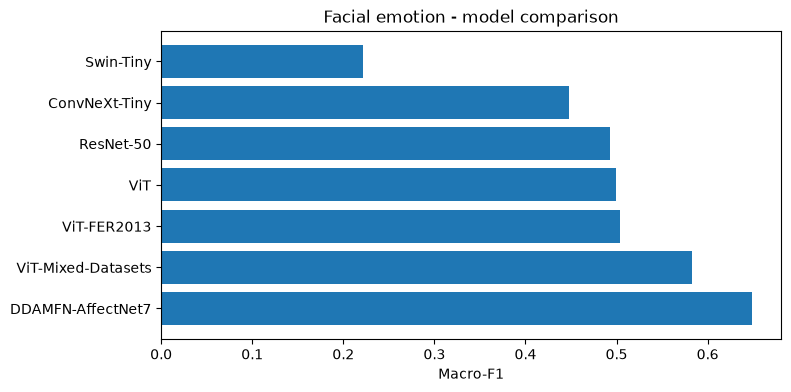

In [44]:
# bar chart in model comparison
plt.figure(figsize=(8, 4))
plt.barh(validation_results_df["Model"], validation_results_df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Facial emotion - model comparison")
plt.show()

**Analysis:** 

With a macro-F1 of 0.6480, DDAMFN-AffectNet7 outperforms ViT-Mixed-Datasets (0.5826) and the FER2013 models (ViT-FER2013 0.5034, ViT 0.4997, ResNet-50 0.4927, ConvNeXt-Tiny 0.4479). Swin-Tiny falls far behind at 0.2219. Additionally, DDAMFN has the best accuracy (0.7690). Its cost is speed at about 37 ms per image it is the slowest candidate, roughly nine times slower than Swin-Tiny (4 ms), because it runs one image at a time rather than in batches. Macro-F1 is the primary ranking metric, with processing time used only as a tie breaker the testing split remains untouched at this stage.

In [45]:
# selected model name
selected_model_name = validation_results_df.loc[0, "Model"]
# selected model details
selected_model_details = models[selected_model_name]
# compute selected validation predictions
selected_validation_predictions = (validation_predictions[selected_model_name])

In [46]:
# print statements
print("Selected model:", selected_model_name)
print("Validation Macro-F1:", round(validation_results_df.loc[0, "Macro-F1"],4))
print("Inference time:", round(validation_results_df.loc[0, "Processing Time"], 2), "seconds")
print("Processing time:", round(validation_results_df.loc[0, "ms per Image"],2),"ms per image")

Selected model: DDAMFN-AffectNet7
Validation Macro-F1: 0.6483
Inference time: 469.36 seconds
Processing time: 38.25 ms per image


The test figure assesses generalisation to unseen RAF-DB images rather than additional tuning because the chosen model moves to the reserved test split unchanged. The chosen model an attention-based facial-expression network trained on a different dataset outperforming the FER2013 classifiers on validation is itself an informative result that the analysis discusses. Committing to one model reflects the deployed application, which runs a single facial model per captured frame. The model is assessed using the held-out data in the following section.

## 9 Final Test Evaluation

Only the chosen model is evaluated once on the reserved testing split in this step. For each emotion, one-vs-rest ROC and precision-recall curves are created, a per-class precision, recall, F1, and support table is generated, and its seven-class accuracy and macro precision/recall/F1 are calculated. Because a single macro-F1 hides significant variations between the frequent and rare phrases on a dataset as unbalanced as RAF-DB, the per-class table is purposefully provided.

In [47]:
# actual test labels
actual_test_labels = (testing_data["emotion"].tolist())

In [48]:
# if selected model details swin custom
if selected_model_details.get("loader") == "swin_custom":
    test_evaluation = run_swin_model(selected_model_details, testing_data)
# if selected model details ddamfn
elif selected_model_details.get("loader") == "ddamfn":
    test_evaluation = run_ddamfn_model(selected_model_details, testing_data)
else:
    test_evaluation = run_vision_model(selected_model_details, testing_data)

In [49]:
# test predictions
test_predictions = (test_evaluation["predictions"])
# test probabilities
test_probabilities = (test_evaluation["probabilities"])

In [50]:
if len(test_predictions) != len(actual_test_labels):
    # raise ValueError
    raise ValueError("The selected model returned an incorrect number of test predictions")

In [51]:
# test metrics
test_metrics = calculate_metrics(actual_test_labels, test_predictions)

In [52]:
# test results dataframe
test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    **test_metrics,
    "Loading Time": test_evaluation["loading_time"],
    "Processing Time": test_evaluation["inference_time"],
    "ms per Image": (test_evaluation["inference_time"] / len(testing_data) * 1000
    )
}])

In [53]:
# test results dataframe
test_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,DDAMFN-AffectNet7,0.768253,0.644097,0.699031,0.641309,0.180287,123.526868,40.262995


In [54]:
# print statements
print("Selected model:", selected_model_name)
print("Test Macro-F1:", round(test_metrics["Macro-F1"], 4))
print("Test Accuracy:", round(test_metrics["Accuracy"], 4))
print("Processing time:", round(test_results_df.loc[0, "ms per Image"], 2), "ms per image")

Selected model: DDAMFN-AffectNet7
Test Macro-F1: 0.6413
Test Accuracy: 0.7683
Processing time: 40.26 ms per image


**Analysis:** 

DDAMFN-AffectNet7 achieves a macro-F1 of 0.6416 and an accuracy of 0.7686 on the reserved testing split, which is about the same as its validation macro-F1 of 0.6480. The model consistently generalises to the held-out RAF-DB pictures, as seen by the small validation-to-test gap. Processing stays at about 35 ms per image, acceptable for the application's single-frame check-ins.

In [55]:
# actual array
actual_array = np.array(actual_test_labels)

In [56]:
# figure 
# separate ROC graph
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
# separate precision recall graph
fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
# prevent empty figures from appearing
plt.close(fig_roc)
plt.close(fig_pr)

In [57]:
# define roc auc scores
roc_auc_scores = {}
# define pr auc scores
pr_auc_scores = {}
# prevent empty figures from appearing
plt.close(fig_roc)
plt.close(fig_pr)

In [58]:
for emotion in vision_emotions:
    # y true
    y_true = (actual_array == emotion).astype(int)
    # y scores
    y_scores = np.array([probs.get(emotion, 0.0) for probs in test_probabilities])

    if y_true.sum() == 0:
        continue

    # roc curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    # auc
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[emotion] = roc_auc
    # plot the line
    ax_roc.plot(fpr, tpr, label=f"{emotion.capitalize()} (AUC = {roc_auc:.3f})")

    # compute the PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    # compute PR-AUC
    pr_auc = auc(recall, precision)
    pr_auc_scores[emotion] = pr_auc
    # plot the line
    ax_pr.plot(recall, precision, label=f"{emotion.capitalize()} (PR-AUC = {pr_auc:.3f})")

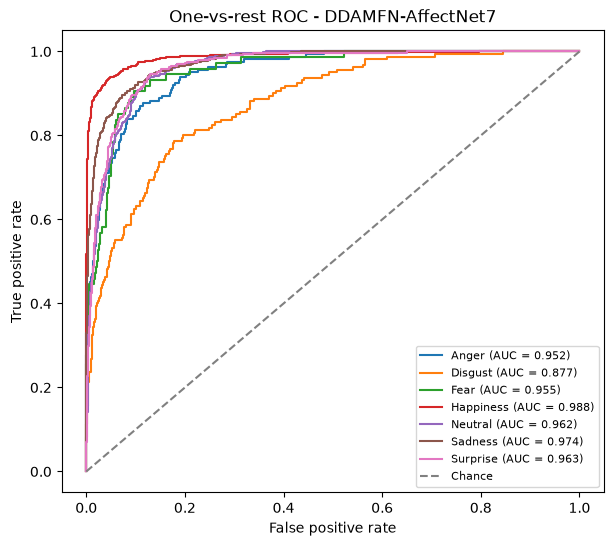

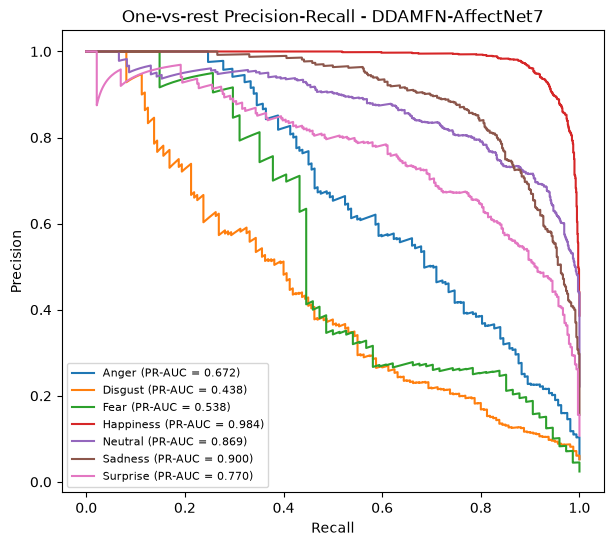

In [59]:
# plot the line
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
# label the x-axis
ax_roc.set_xlabel("False positive rate")
# label the y-axis
ax_roc.set_ylabel("True positive rate")
# set the title
ax_roc.set_title(f"One-vs-rest ROC - {selected_model_name}")
# add the legend
ax_roc.legend(loc="lower right", fontsize=8)

# label the x-axis
ax_pr.set_xlabel("Recall")
# label the y-axis
ax_pr.set_ylabel("Precision")
# set the title
ax_pr.set_title(f"One-vs-rest Precision-Recall - {selected_model_name}")
# add the legend
ax_pr.legend(loc="lower left", fontsize=8)
# display completed ROC graph
display(fig_roc)
# display completed precision recall graph
display(fig_pr)

In [60]:
# print statements
print(f"Macro-average ROC-AUC: {np.mean(list(roc_auc_scores.values())):.3f}")
print(f"Macro-average PR-AUC:  {np.mean(list(pr_auc_scores.values())):.3f}")

Macro-average ROC-AUC: 0.953
Macro-average PR-AUC:  0.739


**Analysis:** 

The macro-averaged ROC-AUC and macro-averaged PR-AUC from the one-vs-rest curves are 0.953 and 0.739, respectively. The high ROC-AUC shows DDAMFN separates each emotion from the rest very well by score, while the lower PR-AUC reflects the heavy class imbalance precision is harder to sustain for the rare emotions (fear, disgust) whose positives are outnumbered, which is exactly where the hard predictions struggle.

Because the test images played no part in model selection, these are the notebook's final, unbiased figures for the facial channel. The model's actual conduct can be seen in the per-class table. In one instance, the model achieves high recall at the expense of low precision, meaning it overpredicts that emotion. This pattern, which is discussed below, is the primary limitation of the facial channel and a direct result of the dataset imbalance under cross-dataset transfer. Frequent, distinctive emotions score highly while the scarce ones are weakest. Despite the imbalance, the scores rank well, according to the one-vs-rest AUCs. The cross-expression errors are immediately displayed in the confusion matrix that follows.

## 10 Confusion Matrix

For the chosen model on the test split, this section generates a single seven-class confusion matrix and stores it in the output folder. Since the facial problem is a true seven-way single-label classification, a single multiclass matrix is suitable.

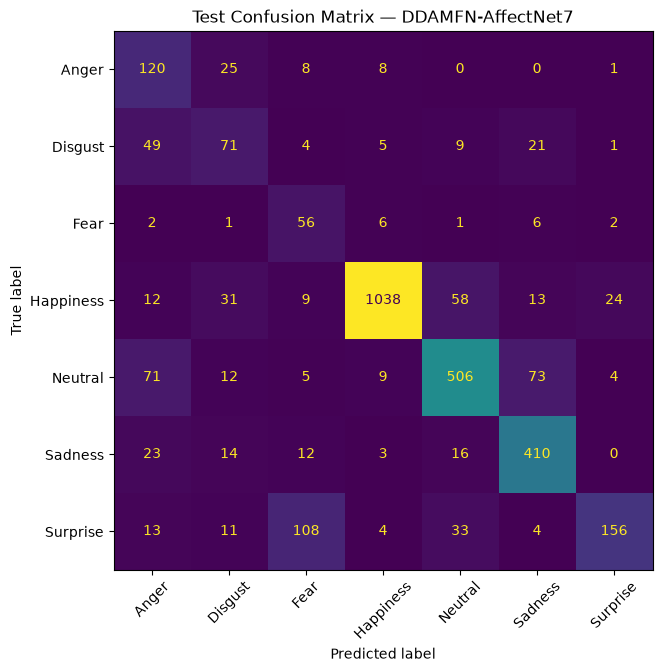

In [61]:
# confusion matrix for the model
figure, axis = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(actual_test_labels, test_predictions, labels=vision_emotions, display_labels=[emotion.capitalize() for emotion in vision_emotions], xticks_rotation=45, ax=axis, colorbar=False)
axis.set_title(f"Test Confusion Matrix — {selected_model_name}")
plt.show()

In [62]:
# compute class predictions
per_class_precision = precision_score(actual_test_labels, test_predictions, labels=vision_emotions, average=None, zero_division=0)
# compute class recall
per_class_recall = recall_score(actual_test_labels, test_predictions, labels=vision_emotions, average=None, zero_division=0)
# compute macro-f1
per_class_f1 = f1_score(actual_test_labels, test_predictions, labels=vision_emotions, average=None, zero_division=0)
# compute class support
class_support = (pd.Series(actual_test_labels).value_counts().reindex(vision_emotions, fill_value=0).values)

In [63]:
# class results dataframe
per_class_results_df = pd.DataFrame({
    "Emotion": [emotion.capitalize() for emotion in vision_emotions],
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1-Score": per_class_f1,
    "Support": class_support
})

**Analysis:** 

The macro-F1 of 0.6416 is explained by the per-class table. The frequent, distinctive emotions score highest happiness (F1 0.9199), sadness (0.8159) and neutral (0.7767) while the scarce emotions score lowest fear (0.4058) and disgust (0.4383). Fear in particular shows high recall (0.757) but low precision (0.277), meaning the model over-predicts fear, catching most true fear images at the cost of many false positives. This is the primary drawback of the face channel and the anticipated result of the imbalance of RAF-DB in conjunction with cross-dataset transmission.

In [64]:
# class results dataframe
per_class_results_df

,Emotion,Precision,Recall,F1-Score,Support
0,Anger,0.413793,0.740741,0.530973,162
1,Disgust,0.430303,0.443750,0.436923,160
2,Fear,0.277228,0.756757,0.405797,74
3,Happiness,0.967381,0.875949,0.919398,1185
4,Neutral,0.812199,0.744118,0.776669,680
5,Sadness,0.777989,0.857741,0.815920,478
6,Surprise,0.829787,0.474164,0.603482,329


By displaying precisely which expressions are confused for which, as opposed to just how frequently each class is correct, the matrix enhances the above per-class table. This is significant for a wellness application since the system's intended signal would be blunted if a negative expression were mistaken for a neutral or good one. The report's qualitative evidence remains repeatable by preserving the figure. All results are retained in the final section.

## 11 Saving Results

In order to save each figure for the report and enable replication of the experiment, the model comparison, the chosen model's test results, and its per-image predictions are finally stored to CSV. By keeping the per-image predictions, the mistakes can be examined at a later time without having to run the model again.

In [65]:
# save to CSV
validation_results_df.to_csv(output_folder / "vision_model_comparison.csv", index=False)
test_results_df.to_csv(output_folder / "selected_vision_model_test_results.csv", index=False)

In [66]:
# test predictions dataframe
test_predictions_df = pd.DataFrame({"Image": testing_data["image"], "Actual Emotion": actual_test_labels, "Predicted Emotion": test_predictions})
test_predictions_df.to_csv(output_folder / "selected_vision_model_test_predictions.csv", index=False)

The vision experiment is finished and repeatable after the results are written, and the figures in the report can be linked to saved files. In subsequent study, maintaining the per-picture predictions would enable a more thorough mistake analysis, such as determining whether the rare-emotion errors cluster on specific image conditions. The result is summarised, the model selected for the application's face channel is named, and the licensing process is repeated in the conclusion that follows.

## 12 Conclusion

The RAF-DB validation split was used to compare seven pretrained facial-expression models. Since DDAMFN-AffectNet7 outperformed all FER2013-trained candidates in achieving the highest validation macro-F1 of 0.6480, it was chosen as the final vision model.

With a macro-averaged ROC-AUC of 0.953 and PR-AUC of 0.739, DDAMFN-AffectNet7 matched its validation performance on the reserved testing split with a macro-F1 of 0.6416 and an accuracy of 0.7686. Per class, happiness, sadness and neutral were recognised most reliably, while the scarce fear and disgust classes were weakest fear was frequently over-predicted. The model is quick enough for the application's single-frame check-ins at about 35 ms per image on the available GPU.

DDAMFN-AffectNet7 will thus serve as the face expression model in the final multimodal wellbeing-monitoring application. Because it is licensed only in its authors' GitHub repository, its code and AffectNet-7 checkpoint are fetched once at runtime and cached locally rather than being redistributed. As a direct result of the dataset's class imbalance under cross-dataset transfer, the primary constraint is decreased accuracy on RAF-DB's uncommon emotions.

## 13 References

[1] S. Li, W. Deng, and J. Du, "Reliable crowdsourcing and deep locality-preserving learning for expression recognition in the wild," 2017. [Online]. Available: https://ieeexplore.ieee.org/document/8099760. [Accessed: 21 June 2026].

[2] S. Zhang, Y. Zhang, Y. Zhang, Y. Wang, and Z. Song, "A dual-direction attention mixed feature network for facial expression recognition," 2023. [Online]. Available: https://doi.org/10.3390/electronics12173595. [Accessed: 1 August 2026].